<a href="https://colab.research.google.com/github/amanilayouni/Amani_Karam_Ryma_arene_ml/blob/main/Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
!git clone https://github.com/amanilayouni/Amani_Karam_Ryma_arene_ml.git
!git branch

fatal: destination path 'Amani_Karam_Ryma_arene_ml' already exists and is not an empty directory.
fatal: not a git repository (or any of the parent directories): .git


In [101]:
# Cellule 1 — Installation des dépendances

!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Installation terminée !")

Installation terminée !


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [102]:
# Cellule 2 — Imports

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import joblib
import warnings, time
warnings.filterwarnings('ignore')

print("Tous les imports OK")

Tous les imports OK


In [103]:
import os
os.environ["KAGGLE_USERNAME"] = "dhifikaram"
os.environ["KAGGLE_KEY"] = "KGAT_ea4dfe62bab9dafeb6d4b690e305dcd5"

In [104]:
!pip install kaggle

In [105]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


In [106]:
!unzip sentiment140.zip

Archive:  sentiment140.zip
replace training.1600000.processed.noemoticon.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [107]:
import pandas as pd

df = pd.read_csv("training.1600000.processed.noemoticon.csv",
                 encoding="latin-1", header=None)
df.columns = ["sentiment", "id", "date", "query", "user", "text"]
df["sentiment"] = df["sentiment"].replace(4, 1)

print(f"Dataset complet : {df.shape}")
print(df["sentiment"].value_counts())

Dataset complet : (1600000, 6)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [108]:
# Sous-échantillonnage 100k (50k par classe)
N_PAR_CLASSE = 50_000

df = (df
    .groupby("sentiment")
    .sample(N_PAR_CLASSE, random_state=42)
    .reset_index(drop=True)
)

print(f" Dataset : {len(df):,} tweets")
print(f"   Négatif : {(df['sentiment']==0).sum():,}")
print(f"   Positif : {(df['sentiment']==1).sum():,}")

 Dataset : 100,000 tweets
   Négatif : 50,000
   Positif : 50,000


In [109]:
# Aperçu du dataset
print(f"\n Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f" Colonnes : {list(df.columns)}")
print("\n Premières lignes :")
df.head(3)


 Dimensions : 100000 lignes x 6 colonnes
 Colonnes : ['sentiment', 'id', 'date', 'query', 'user', 'text']

 Premières lignes :


,sentiment,id,date,query,user,text
0,0,1974671194,Sat May 30 13:36:31 PDT 2009,NO_QUERY,simba98,@xnausikaax oh no! where did u order from? tha...
1,0,1997882236,Mon Jun 01 17:37:11 PDT 2009,NO_QUERY,Seve76,A great hard training weekend is over. a coup...
2,0,2177756662,Mon Jun 15 06:39:05 PDT 2009,NO_QUERY,x__claireyy__x,"Right, off to work Only 5 hours to go until I..."


 Valeurs manquantes :
text         0
sentiment    0
dtype: int64

 Distribution :
sentiment
Négatif    50000
Positif    50000
Name: count, dtype: int64


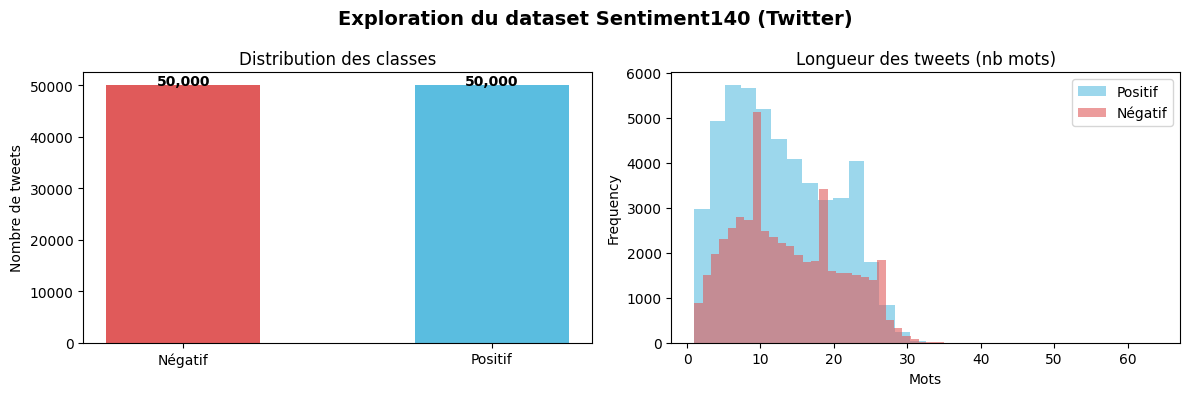


 Longueur moyenne : 13 mots
   Min : 1 | Max : 64


In [110]:
# Cellule Exploration — Sentiment140

import matplotlib.pyplot as plt

# Garder uniquement les colonnes utiles
df = df[["text", "sentiment"]]

# Valeurs manquantes
print(" Valeurs manquantes :")
print(df.isnull().sum())

# Distribution
print("\n Distribution :")
print(df["sentiment"].value_counts().rename({0: 'Négatif', 1: 'Positif'}))

# Longueur
df['nb_mots'] = df['text'].str.split().str.len()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Exploration du dataset Sentiment140 (Twitter)', fontsize=14, fontweight='bold')

counts = df['sentiment'].value_counts().rename({0: 'Négatif', 1: 'Positif'})
axes[0].bar(counts.index, counts.values, color=['#E05A5A', '#5ABDE0'], width=0.5)
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel("Nombre de tweets")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha='center', fontweight='bold')

df[df['sentiment']==1]['nb_mots'].plot(kind='hist', bins=30,
    alpha=0.6, color='#5ABDE0', label='Positif', ax=axes[1])
df[df['sentiment']==0]['nb_mots'].plot(kind='hist', bins=30,
    alpha=0.6, color='#E05A5A', label='Négatif', ax=axes[1])
axes[1].set_title('Longueur des tweets (nb mots)')
axes[1].set_xlabel('Mots')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\n Longueur moyenne : {df['nb_mots'].mean():.0f} mots")
print(f"   Min : {df['nb_mots'].min()} | Max : {df['nb_mots'].max()}")

In [111]:
# Cellule 6 — Fonction de nettoyage du texte

# Configuration
STOPWORDS = set(stopwords.words('english'))
# On garde les négations — elles portent du sentiment !
STOPWORDS -= {'no','not','nor','never','nothing','wasn','isn','won'}
lemmatizer = WordNetLemmatizer()

def nettoyer_texte(texte):
    """Nettoie un avis en 6 étapes."""
    # Étape 1 : minuscules
    texte = str(texte).lower()
    # Étape 2 : suppression des balises HTML (<br />, etc.)
    texte = re.sub(r'<[^>]+>', ' ', texte)
    # Étape 3 : suppression ponctuation et chiffres
    texte = re.sub(r'[^a-zs]', ' ', texte)
    # Étape 4 : suppression espaces multiples
    texte = re.sub(r's+', ' ', texte).strip()
    # Étape 5 : tokenisation + suppression stopwords
    tokens = [t for t in texte.split() if t not in STOPWORDS and len(t) > 2]
    # Étape 6 : lemmatisation (runs → run, better → good)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Test visuel avant / après
exemple = df['text'].iloc[0]
print("AVANT :", exemple[:200])
print("\nAPRÈS :", nettoyer_texte(exemple)[:200])

AVANT : @xnausikaax oh no! where did u order from? that's horrible 

APRÈS : xnau ikaax order horrible


In [112]:
# Cellule 7 — Application du preprocessing sur tout le dataset

print(" Nettoyage en cours (1-2 min sur Colab)...")
t0 = time.time()

df['clean_review'] = df['text'].apply(nettoyer_texte)

elapsed = time.time() - t0
print(f"Terminé en {elapsed:.1f}s")

# Vérification : longueur avant / après
df['mots_avant'] = df['text'].str.split().str.len()
df['mots_apres'] = df['clean_review'].str.split().str.len()

print(f"\n Réduction moyenne : {df['mots_avant'].mean():.0f} → {df['mots_apres'].mean():.0f} mots")
print(f"   (soit -{(1 - df['mots_apres'].mean()/df['mots_avant'].mean())*100:.0f}% de mots)")

# Aperçu
df[['text', 'clean_review', 'sentiment']].head(2)

 Nettoyage en cours (1-2 min sur Colab)...
Terminé en 4.7s

 Réduction moyenne : 13 → 7 mots
   (soit -45% de mots)


,text,clean_review,sentiment
0,@xnausikaax oh no! where did u order from? tha...,xnau ikaax order horrible,0
1,A great hard training weekend is over. a coup...,great hard training weekend couple day let lot...,0


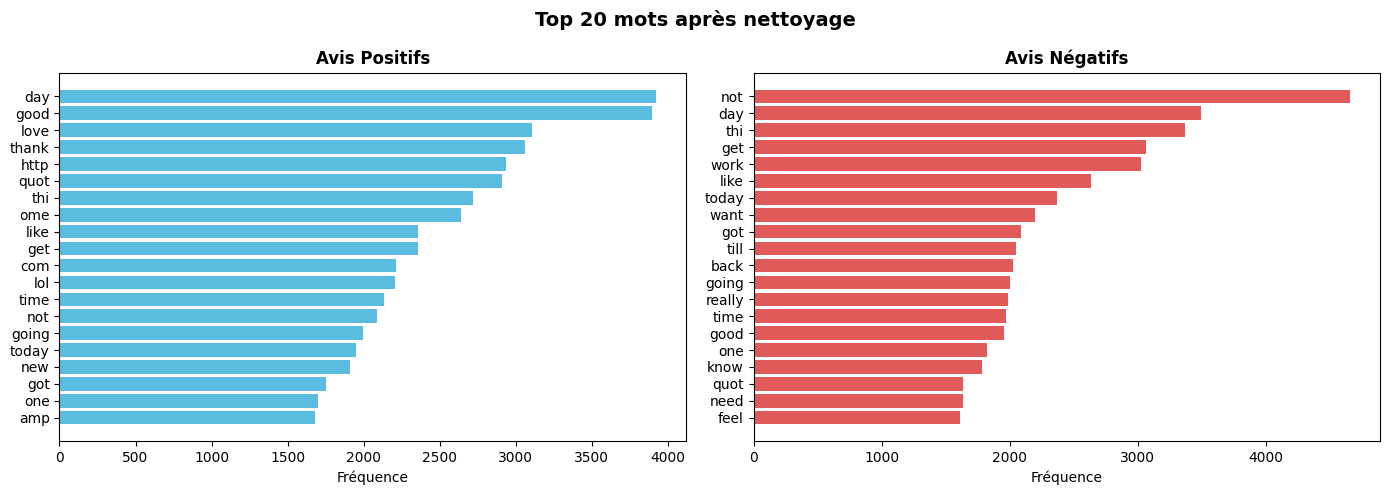

In [113]:
# Cellule 8 — Top mots positifs vs négatifs
from collections import Counter

def top_mots(series, n=20):
    return Counter(' '.join(series).split()).most_common(n)

pos_mots = top_mots(df[df['sentiment']==1]['clean_review'])
neg_mots = top_mots(df[df['sentiment']==0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 20 mots après nettoyage', fontsize=14, fontweight='bold')

for ax, mots, couleur, titre in zip(
    axes,
    [pos_mots, neg_mots],
    ['#5ABDE0', '#E05A5A'],
    ['Avis Positifs', 'Avis Négatifs']
):
    mots_df = pd.DataFrame(mots, columns=['mot', 'count'])
    ax.barh(mots_df['mot'][::-1], mots_df['count'][::-1], color=couleur)
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.show()

In [114]:
# Cellule 9 — Séparation Train / Test

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y             # même distribution dans train et test
)

print(f"   Train : {len(X_train):,} exemples")
print(f"   Test  : {len(X_test):,} exemples")
print(f"\n   Ratio positifs — Train : {y_train.mean():.1%} | Test : {y_test.mean():.1%}")

   Train : 80,000 exemples
   Test  : 20,000 exemples

   Ratio positifs — Train : 50.0% | Test : 50.0%


In [115]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

print("Baseline accuracy :", accuracy_score(y_test, y_pred))

Baseline accuracy : 0.7452


In [116]:
# CELLULE 9 — DÉFINITION DES MODELES (PIPELINES TF-IDF)


from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# PARAMÈTRES TF-IDF (BASE COMMUNE)

TFIDF_PARAMS = {
    "max_features": 30000,
    "ngram_range": (1, 2),
    "sublinear_tf": True,
    "min_df": 3
}

# MODELES ("COMBATTANTS")

combattants = {
    "Naive Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),

    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ]),

    "SVM": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=2000)
        ))
    ]),

    "Random Forest": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            n_jobs=-1,
            random_state=42
        ))
    ]),
}

# AFFICHAGE

print(f"{len(combattants)} modèles prêts pour l'Arène !\n")

for nom in combattants:
    print("   ·", nom)

4 modèles prêts pour l'Arène !

   · Naive Bayes
   · Logistic Regression
   · SVM
   · Random Forest


In [117]:
# CELLULE 11 — ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES

import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)

resultats = {}

print(f"{'─'*70}")
print(f"{'MODÈLE':<22} {'F1':>8} {'AUC':>8} {'TEMPS':>10}")
print(f"{'─'*70}")

for nom, pipeline in combattants.items():

    # ENTRAÎNEMENT

    t0 = time.time()
    pipeline.fit(X_train, y_train)
    duree = time.time() - t0

    # PRÉDICTIONS
    y_pred = pipeline.predict(X_test)

    # certains modèles n'ont pas predict_proba
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = pipeline.decision_function(X_test)

    # MÉTRIQUES
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    f1 = f1_score(y_test, y_pred)

    resultats[nom] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1,
        "ROC-AUC": auc_score,
        "Temps": round(duree, 1),
        "y_pred": y_pred,
        "y_proba": y_proba,
        "pipeline": pipeline
    }

    print(f"{nom:<22} {f1:>8.4f} {auc_score:>8.4f} {duree:>8.1f}s")

print(f"{'─'*70}")
print("Arène terminée !")

──────────────────────────────────────────────────────────────────────
MODÈLE                       F1      AUC      TEMPS
──────────────────────────────────────────────────────────────────────
Naive Bayes              0.7229   0.8026      4.1s
Logistic Regression      0.7535   0.8315      3.6s
SVM                      0.7419   0.8181      9.4s
Random Forest            0.7334   0.8072    914.4s
──────────────────────────────────────────────────────────────────────
Arène terminée !


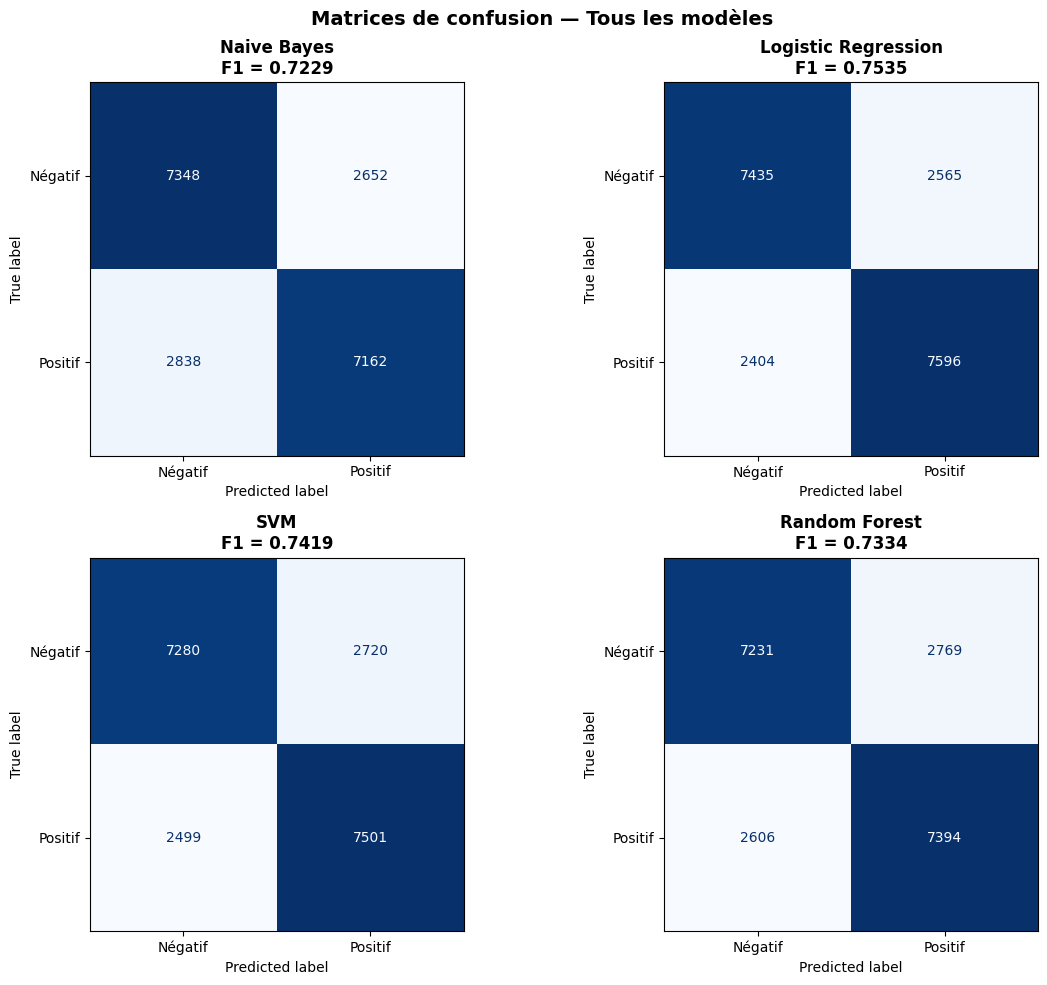


 Rapport détaillé — Logistic Regression :

              precision    recall  f1-score   support

     Négatif       0.76      0.74      0.75     10000
     Positif       0.75      0.76      0.75     10000

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



In [118]:
# Cellule 12 — Matrices de confusion des 4 modèles

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrices de confusion — Tous les modèles', fontsize=14, fontweight='bold')

for ax, (nom, res) in zip(axes.flat, resultats.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1 = res['F1-score']
    ax.set_title(f"{nom}\nF1 = {f1:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

# Rapport complet du meilleur modèle
meilleur = max(resultats, key=lambda k: resultats[k]['F1-score'])
print(f"\n Rapport détaillé — {meilleur} :\n")
print(classification_report(
    y_test, resultats[meilleur]['y_pred'],
    target_names=['Négatif', 'Positif']
))

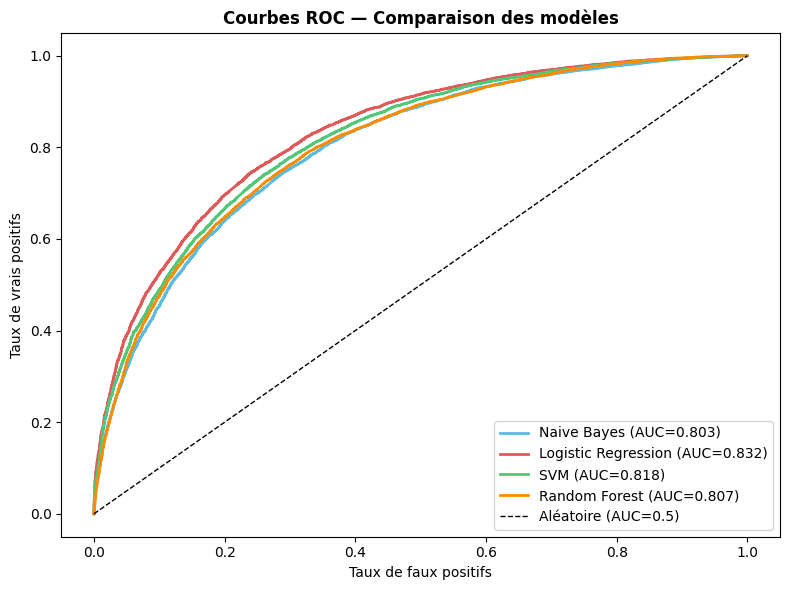

In [119]:
# Cellule 13 — Courbes ROC comparées

fig, ax = plt.subplots(figsize=(8, 6))
couleurs = ['#5ABDE0', '#E05A5A', '#50C878', '#FF8C00']

for (nom, res), couleur in zip(resultats.items(), couleurs):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    score = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=couleur,
            label=f"{nom} (AUC={score:.3f})")

# Ligne de base (modèle aléatoire)
ax.plot([0,1], [0,1], 'k--', lw=1, label='Aléatoire (AUC=0.5)')

ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [120]:
# Cellule 14 — Leaderboard et désignation du champion

# Construction du tableau
leaderboard = pd.DataFrame({
    nom: {k: v for k, v in res.items()
          if k not in ('y_pred', 'y_proba', 'pipeline')}
    for nom, res in resultats.items()
}).T.sort_values('F1-score', ascending=False)

print("\n LEADERBOARD FINAL :\n")
cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Temps']
print(leaderboard[cols].round(4).to_string())

# Désignation du champion
champion_nom  = leaderboard.index[0]
champion_pipe = resultats[champion_nom]['pipeline']

print(f"""
 CHAMPION : {champion_nom}
{'─'*45}
Justification :
  · Meilleur F1-score = {leaderboard.iloc[0]['F1-score']:.4f}
  · Meilleur AUC      = {leaderboard.iloc[0]['ROC-AUC']:.4f}
  · Rapide ({leaderboard.iloc[0]['Temps']}s) → déployable en production
  · Coefficients interprétables (explicabilité)
""")
# Validation croisée 5-fold pour confirmer la robustesse
print(" Validation croisée 5-fold...")
scores_cv = cross_val_score(champion_pipe, X, y, cv=5, scoring='f1')
print(f"   F1 moyen : {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print("    Champion stable — pas un résultat chanceux !")


 LEADERBOARD FINAL :

                     Accuracy  Precision  Recall  F1-score  ROC-AUC  Temps
Logistic Regression    0.7516     0.7476  0.7596    0.7535   0.8315    3.6
SVM                    0.7390     0.7339  0.7501    0.7419   0.8181    9.4
Random Forest          0.7312     0.7275  0.7394    0.7334   0.8072  914.4
Naive Bayes            0.7255     0.7298  0.7162    0.7229   0.8026    4.1

 CHAMPION : Logistic Regression
─────────────────────────────────────────────
Justification :
  · Meilleur F1-score = 0.7535
  · Meilleur AUC      = 0.8315
  · Rapide (3.6s) → déployable en production
  · Coefficients interprétables (explicabilité)

 Validation croisée 5-fold...
   F1 moyen : 0.7524 ± 0.0022
    Champion stable — pas un résultat chanceux !


In [121]:
# Cellule 15 — Sauvegarde du pipeline champion

import os
os.makedirs('model', exist_ok=True)

# Sauvegarde du pipeline complet (TF-IDF + classificateur)
joblib.dump(champion_pipe, 'model/champion.joblib')
print(" Pipeline sauvegardé → model/champion.joblib")

# Vérification : rechargement et test
pipeline_charge = joblib.load('model/champion.joblib')
test_avis = nettoyer_texte("This movie was absolutely fantastic!")
pred = pipeline_charge.predict([test_avis])[0]
proba = pipeline_charge.predict_proba([test_avis])[0]

print(f"\n Test de rechargement :")
print(f"   Avis    : 'This movie was absolutely fantastic!'")
print(f"   Prédit  : {'Positif' if pred==1 else 'Négatif'}")
print(f"   Confiance : {max(proba):.1%}")
print("\n Le modèle est prêt pour la WebApp !")

 Pipeline sauvegardé → model/champion.joblib

 Test de rechargement :
   Avis    : 'This movie was absolutely fantastic!'
   Prédit  : Positif
   Confiance : 69.0%

 Le modèle est prêt pour la WebApp !


In [122]:
# Cellule 16 — Tests adversariaux

cas_tests = [
    ("This movie was absolutely fantastic and I loved every second!", "Happy path "),
    ("Terrible film, complete waste of time. Awful acting.",         "Happy path "),
    ("Good.",                                                         "Très court"),
    ("ok",                                                            "Trop court"),
    ("Thsi moovie wass amazng!!!",                                    "Fautes d'orthographe"),
    ("The acting was terrible but the story was amazing.",            "Ambigu"),
    ("Not bad at all, I did not hate it.",                           "Double négation"),
    ("",                                                              "Vide"),
]

print(f"{'─'*72}")
print(f"{'AVIS':<40} {'PRÉDIT':<10} {'CONFIANCE':<12} TYPE")
print(f"{'─'*72}")

for texte, type_test in cas_tests:
    if not texte.strip():
        print(f"{'(vide)':<40} {'—':<10} {'—':<12} {type_test}")
        continue
    clean = nettoyer_texte(texte)
    if not clean:
        print(f"{texte[:40]:<40} {'—':<10} {'—':<12} {type_test} (aucun token)")
        continue
    pred  = champion_pipe.predict([clean])[0]
    proba = champion_pipe.predict_proba([clean])[0]
    label = 'Positif' if pred==1 else 'Négatif'
    conf  = f"{max(proba):.1%}"
    print(f"{texte[:40]:<40} {label:<10} {conf:<12} {type_test}")

print(f"{'─'*72}")

────────────────────────────────────────────────────────────────────────
AVIS                                     PRÉDIT     CONFIANCE    TYPE
────────────────────────────────────────────────────────────────────────
This movie was absolutely fantastic and  Positif    75.2%        Happy path 
Terrible film, complete waste of time. A Négatif    93.1%        Happy path 
Good.                                    Positif    97.7%        Très court
ok                                       —          —            Trop court (aucun token)
Thsi moovie wass amazng!!!               Positif    53.7%        Fautes d'orthographe
The acting was terrible but the story wa Négatif    72.0%        Ambigu
Not bad at all, I did not hate it.       Négatif    95.1%        Double négation
(vide)                                   —          —            Vide
────────────────────────────────────────────────────────────────────────


In [125]:
# Cellule 17 — Génération de la WebApp Streamlit

%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOPWORDS = set(stopwords.words("english")) - {"no", "not", "nor", "never"}
lemmatizer = WordNetLemmatizer()

def clean(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"#", "", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    tokens = [
        lemmatizer.lemmatize(w)
        for w in t.split()
        if w not in STOPWORDS and len(w) > 2
    ]

    return " ".join(tokens)

@st.cache_resource
def load_model():
    return joblib.load("model/champion.joblib")

model = load_model()

st.title("Sentiment Analyzer")
st.write("Entrez un tweet ou un avis en anglais pour prédire son sentiment.")

avis = st.text_area("Votre texte", height=120)

if st.button("Analyser", type="primary"):
    if not avis.strip():
        st.warning("Veuillez entrer un texte.")
    else:
        texte_clean = clean(avis)

        if texte_clean == "":
            st.warning("Le texte est vide après nettoyage.")
        else:
            pred = model.predict([texte_clean])[0]
            label = "Positif" if pred == 1 else "Négatif"

            st.success(f"Sentiment prédit : {label}")

            if hasattr(model, "predict_proba"):
                proba = model.predict_proba([texte_clean])[0]
                confiance = max(proba)
                st.metric("Confiance", f"{confiance:.1%}")
                st.progress(float(confiance))
            else:
                st.info("Ce modèle ne fournit pas de probabilité.")

            st.write("Texte nettoyé :")
            st.code(texte_clean)

Overwriting app.py
